**Exp 10. Iris Flower Classification: Use the Iris dataset to build a classification model that
predicts the species of iris flowers. [Dataset: Load dataset from sklearn]**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
import pickle

In [2]:
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df['species']=iris.target
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [3]:
print(df.shape)
print(df.info)
df.describe()

(150, 5)
<bound method DataFrame.info of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1         

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
print(df['species'].value_counts())

species
0    50
1    50
2    50
Name: count, dtype: int64


In [5]:
df['species_name']=df['species'].map({0:'setosa',1:'versicolor',2:'virginica'})
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


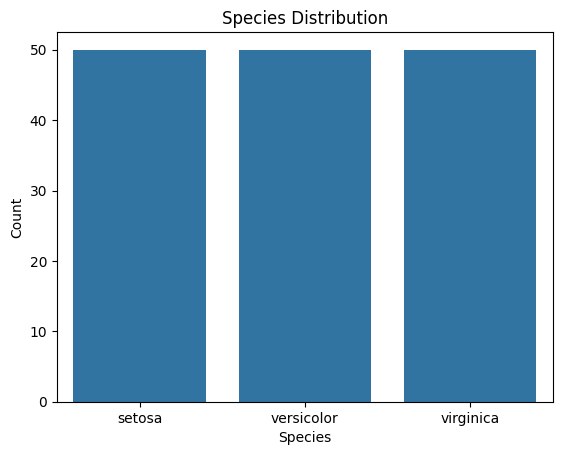

In [6]:
sns.countplot(x='species_name',data=df)
plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

In [7]:
X=df[iris.feature_names]
y=df['species']

In [8]:
sc=StandardScaler()
X_scaled=sc.fit_transform(X)

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=0,stratify=y)
print("Train size:",X_train.shape)
print("Test size:",X_test.shape)

Train size: (120, 4)
Test size: (30, 4)


In [10]:
models={
"Logistic Regression":LogisticRegression(max_iter=1000),
"Random Forest":RandomForestClassifier(),
"Decision Tree":DecisionTreeClassifier(),
"KNN":KNeighborsClassifier(),
"SVM":SVC()
}

In [11]:
results=[]
for name,model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    acc=accuracy_score(y_test,pred)
    pre=precision_score(y_test,pred,average='weighted')
    rec=recall_score(y_test,pred,average='weighted')
    f1w=f1_score(y_test,pred,average='weighted')
    f1m=f1_score(y_test,pred,average='macro')
    f1mi=f1_score(y_test,pred,average='micro')
    results.append([name,acc,pre,rec,f1w,f1m,f1mi])

In [12]:
results_df=pd.DataFrame(results,columns=["Model","Accuracy","Precision","Recall","F1_weighted","F1_macro","F1_micro"])
results_df

,Model,Accuracy,Precision,Recall,F1_weighted,F1_macro,F1_micro
0,Logistic Regression,0.966667,0.969697,0.966667,0.966583,0.966583,0.966667
1,Random Forest,0.933333,0.944444,0.933333,0.932660,0.932660,0.933333
2,Decision Tree,0.966667,0.969697,0.966667,0.966583,0.966583,0.966667
3,KNN,0.966667,0.969697,0.966667,0.966583,0.966583,0.966667
4,SVM,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


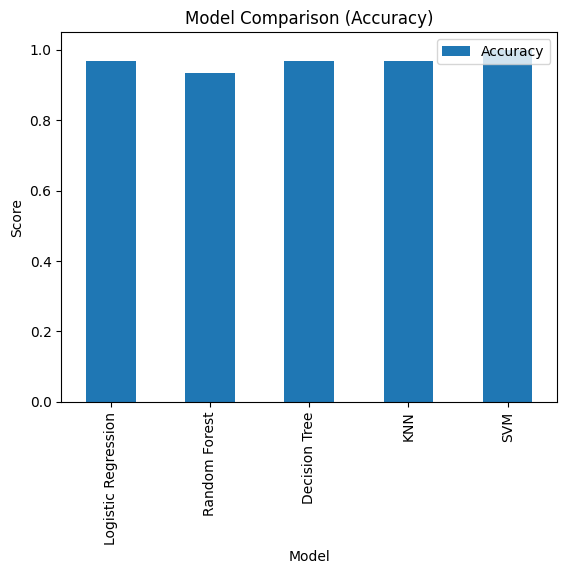

In [13]:
results_df.plot(x="Model",y="Accuracy",kind="bar")
plt.title("Model Comparison (Accuracy)")
plt.ylabel("Score")
plt.show()

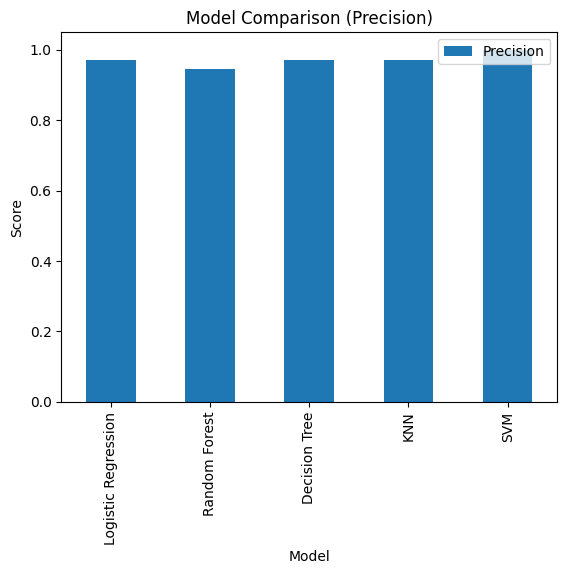

In [14]:
results_df.plot(x="Model",y="Precision",kind="bar")
plt.title("Model Comparison (Precision)")
plt.ylabel("Score")
plt.show()

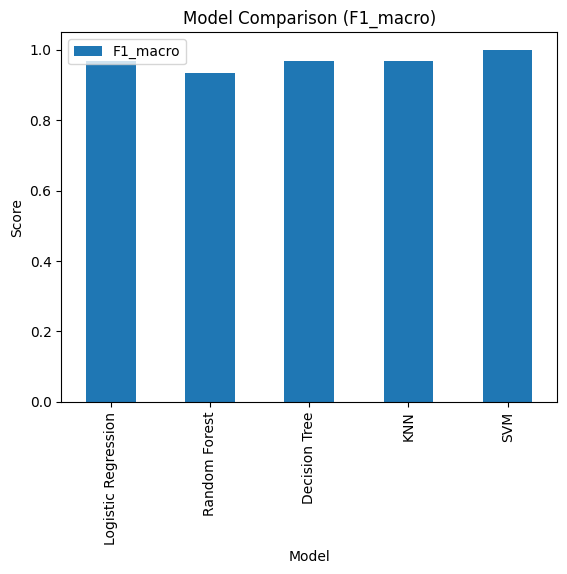

In [15]:
results_df.plot(x="Model",y="F1_macro",kind="bar")
plt.title("Model Comparison (F1_macro)")
plt.ylabel("Score")
plt.show()

In [16]:
best_name=results_df.sort_values("F1_macro",ascending=False).iloc[0,0]
best_model=models[best_name]
print("Best Model:",best_name)

Best Model: SVM


In [17]:
with(open("best_model","wb")) as f:
  pickle.dump(best_model,f)

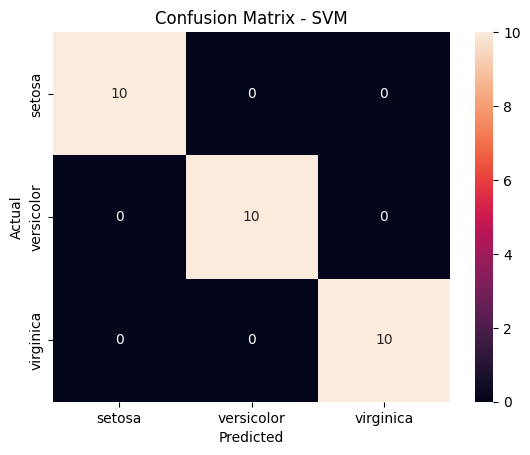

In [18]:
pred=best_model.predict(X_test)
cm=confusion_matrix(y_test,pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix - "+best_name)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0.5,1.5,2.5],['setosa','versicolor','virginica'])
plt.yticks([0.5,1.5,2.5],['setosa','versicolor','virginica'])
plt.show()


In [20]:
print(classification_report(y_test,pred,target_names=['setosa','versicolor','virginica']))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

